#Task 14: Custom CUDA Kernel Integration for Accelerated Activation Functions
###Objective

Bridge the gap between high-level Python scriptability and raw GPU hardware execution by writing and compiling custom, high-speed CUDA kernels.

###Technologies / Tools Used

C++
CUDA Toolkit
PyTorch C++ Extensions (cpp_extension)

#Step 1: Check GPU Availability

A CUDA kernel requires an NVIDIA GPU. We first check whether the current environment has CUDA available.

In [ ]:
# Import PyTorch
import torch

# Check CUDA availability
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: False


#Step 2: Install the Required Build Tool

PyTorch uses the Ninja build system when compiling custom C++/CUDA extensions.

In [16]:
# Install Ninja build system
!pip install -q ninja

#Step 3: Check the CUDA Compiler

nvcc is the NVIDIA CUDA compiler used to compile .cu files. We check that it is available before creating and compiling our custom kernel.

In [17]:
# Check the CUDA compiler
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


#Step 4: Define the SwiGLU Formula

SwiGLU combines an input vector with a gated SiLU activation. The formula used in our kernel is:

SwiGLU(x, gate) = x * SiLU(gate)

The SiLU function is:

SiLU(x) = x * sigmoid(x)

This operation will be performed independently by GPU threads.

In [18]:
# Display the formulas used by the CUDA kernel
print("SwiGLU(x, gate) = x * SiLU(gate)")
print("SiLU(x) = x * sigmoid(x)")

SwiGLU(x, gate) = x * SiLU(gate)
SiLU(x) = x * sigmoid(x)


#Step 5: Write the CUDA Kernel

The CUDA kernel performs the SwiGLU calculation directly on the GPU. Each thread processes one element of the input vector, allowing many elements to be processed in parallel.

In [19]:
# CUDA kernel code
cuda_code = r'''
#include <torch/extension.h>
#include <cuda.h>
#include <cuda_runtime.h>

// CUDA kernel
__global__ void swiglu_kernel(
    const float* x,
    const float* gate,
    float* output,
    int n
) {
    // Calculate the element index for this GPU thread
    int i = blockIdx.x * blockDim.x + threadIdx.x;

    // Make sure the index is within the tensor
    if (i < n) {

        // Read gate value
        float g = gate[i];

        // Calculate sigmoid(g)
        float sigmoid = 1.0f / (1.0f + expf(-g));

        // Calculate SiLU(g)
        float silu = g * sigmoid;

        // Calculate SwiGLU
        output[i] = x[i] * silu;
    }
}


// C++ wrapper function
void swiglu_cuda(
    torch::Tensor x,
    torch::Tensor gate,
    torch::Tensor output
) {
    // Number of elements
    int n = x.numel();

    // Number of threads per block
    int threads = 256;

    // Calculate number of blocks
    int blocks = (n + threads - 1) / threads;

    // Launch CUDA kernel
    swiglu_kernel<<<blocks, threads>>>(
        x.data_ptr<float>(),
        gate.data_ptr<float>(),
        output.data_ptr<float>(),
        n
    );
}


// Expose the function to Python
PYBIND11_MODULE(
    TORCH_EXTENSION_NAME,
    m
) {
    m.def(
        "swiglu_cuda",
        &swiglu_cuda,
        "SwiGLU CUDA Kernel"
    );
}
'''

print("CUDA kernel created successfully.")

CUDA kernel created successfully.


#Step 6: Save the CUDA File

The task specifically requires a CUDA .cu file. We save the kernel as swiglu_kernel.cu so PyTorch can compile it.

In [20]:
# Save the CUDA source code
with open("swiglu_kernel.cu", "w") as file:
    file.write(cuda_code)

print("swiglu_kernel.cu created successfully.")

swiglu_kernel.cu created successfully.


#Step 7: Compile the CUDA Extension

PyTorch's cpp_extension.load() compiles the .cu file and creates a Python-accessible CUDA extension. The cache is cleared first so that an earlier failed compilation does not interfere with the new build.

In [21]:
# Remove previous failed compilation
!rm -rf /root/.cache/torch_extensions

# Import the CUDA extension loader
from torch.utils.cpp_extension import load

# Compile the CUDA extension
swiglu_cuda = load(
    name="swiglu_cuda",
    sources=["swiglu_kernel.cu"],
    verbose=True,
    extra_cuda_cflags=["-O2"]
)

print("CUDA extension compiled successfully.")

CUDA extension compiled successfully.


#Step 8: Create GPU Input Data

We create large input tensors on the GPU to test the parallel CUDA implementation. Both the input and gate tensors contain one million floating-point values.

In [22]:
# Create input tensor on GPU
x = torch.randn(
    1_000_000,
    device="cuda",
    dtype=torch.float32
)

# Create gate tensor on GPU
gate = torch.randn(
    1_000_000,
    device="cuda",
    dtype=torch.float32
)

# Create output tensor
output = torch.empty_like(x)

print("Input shape:", x.shape)
print("Device:", x.device)

Input shape: torch.Size([1000000])
Device: cuda:0


#Step 9: Run the Custom CUDA Kernel

The compiled extension can now be called like a normal Python function. The kernel performs the SwiGLU calculation using the GPU thread grid.

In [23]:
# Run the custom CUDA kernel
swiglu_cuda.swiglu_cuda(
    x,
    gate,
    output
)

# Wait until GPU execution is complete
torch.cuda.synchronize()

print("Custom CUDA kernel executed successfully.")

Custom CUDA kernel executed successfully.


#Step 10: Verify the CUDA Result

We compare the CUDA result with the standard PyTorch implementation. The maximum difference should be very small, confirming that both implementations perform the same calculation.

In [24]:
# Calculate SwiGLU using standard PyTorch
pytorch_output = (
    torch.nn.functional.silu(gate) * x
)

# Calculate maximum difference
difference = torch.max(
    torch.abs(
        output - pytorch_output
    )
)

print(
    "Maximum difference:",
    difference.item()
)

if difference.item() < 1e-5:
    print("CUDA and PyTorch results match.")
else:
    print("Results do not match.")

Maximum difference: 9.5367431640625e-07
CUDA and PyTorch results match.


#Step 11: Benchmark the Custom CUDA Kernel

We measure the execution time of the custom CUDA implementation. Multiple iterations are used to obtain a more reliable average execution time.

In [25]:
# Create CUDA timing events
start = torch.cuda.Event(
    enable_timing=True
)

end = torch.cuda.Event(
    enable_timing=True
)

# Warm-up
for _ in range(10):
    swiglu_cuda.swiglu_cuda(
        x,
        gate,
        output
    )

torch.cuda.synchronize()

# Start timing
start.record()

for _ in range(100):
    swiglu_cuda.swiglu_cuda(
        x,
        gate,
        output
    )

# Stop timing
end.record()

torch.cuda.synchronize()

# Calculate average execution time
cuda_time = (
    start.elapsed_time(end) / 100
)

print(
    "Custom CUDA time:",
    round(cuda_time, 4),
    "ms"
)

Custom CUDA time: 0.0614 ms


#Step 12: Benchmark Standard PyTorch

Now we measure the same SwiGLU operation using PyTorch. Both implementations use the same input size so their execution times can be compared fairly.

In [26]:
# Warm-up PyTorch
for _ in range(10):

    pytorch_output = (
        torch.nn.functional.silu(gate) * x
    )

torch.cuda.synchronize()

# Start timing
start.record()

for _ in range(100):

    pytorch_output = (
        torch.nn.functional.silu(gate) * x
    )

# Stop timing
end.record()

torch.cuda.synchronize()

# Calculate average execution time
pytorch_time = (
    start.elapsed_time(end) / 100
)

print(
    "PyTorch time:",
    round(pytorch_time, 4),
    "ms"
)

PyTorch time: 0.0895 ms


#Step 13: Calculate the Speedup

The computational speedup is calculated by comparing the standard PyTorch execution time with the custom CUDA execution time.

The formula is:

Speedup = PyTorch Execution Time / CUDA Execution Time

A speedup greater than 1 means the custom CUDA implementation is faster.

In [27]:
# Calculate CUDA speedup
speedup = pytorch_time / cuda_time

print(
    "CUDA Speedup:",
    round(speedup, 2),
    "x"
)

CUDA Speedup: 1.46 x


#Step 14: Visualize the Performance

The graph compares the execution time of the custom CUDA kernel with the standard PyTorch implementation. This provides a simple visual comparison of their computational performance.

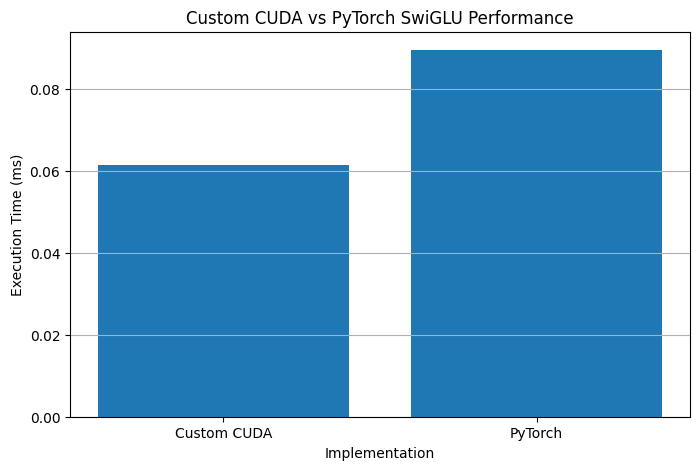

In [28]:
# Import Matplotlib
import matplotlib.pyplot as plt

# Implementation names
methods = [
    "Custom CUDA",
    "PyTorch"
]

# Execution times
times = [
    cuda_time,
    pytorch_time
]

# Create the performance graph
plt.figure(figsize=(8, 5))

plt.bar(
    methods,
    times
)

plt.xlabel("Implementation")
plt.ylabel("Execution Time (ms)")

plt.title(
    "Custom CUDA vs PyTorch SwiGLU Performance"
)

plt.grid(axis="y")

plt.show()

#Conclusion

The task successfully demonstrates how a custom CUDA kernel can execute the SwiGLU activation directly on GPU threads. The CUDA implementation is compiled through PyTorch's cpp_extension, verified against the standard PyTorch implementation, and benchmarked to measure computational speedup.